# Commodities Query — Trading Economics Categories

Queries commodity prices organized under Trading Economics' own category taxonomy — Energy, Metals, Agricultural, Industrial, Livestock, Index, Electricity — for whichever of the ~102 named commodities have a free, identity-verified ticker on Yahoo Finance.

**Coverage: 32 of ~102 items (~31%).** The rest — regional gas/power hubs, rare earths, petrochemicals, national electricity prices, freight and carbon indices — trade on specialty exchanges or OTC markets that require a paid feed (Trading Economics, Platts/Argus, Fastmarkets, LME) this project has no key for. Each section below fetches what's available and documents what isn't, rather than omitting or faking the rest.

This is a standalone survey notebook: it queries `yfinance` directly (like `fx_ohlcv_query.ipynb`) and does **not** add series to `catalog.yaml` or persist through the `macro_data` package's store.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_rows", 30)
%matplotlib inline


def fetch_latest(items: dict[str, tuple[str, str]]) -> pd.DataFrame:
    """items: {name: (ticker, unit)}. Returns the latest close per ticker; skips tickers with no data."""
    rows = []
    for name, (ticker, unit) in items.items():
        try:
            hist = yf.Ticker(ticker).history(period="5d")
            if hist.empty:
                raise ValueError("no data returned")
            latest = hist.iloc[-1]
            rows.append(
                {
                    "item": name,
                    "ticker": ticker,
                    "date": hist.index[-1].date(),
                    "price": round(float(latest["Close"]), 4),
                    "unit": unit,
                }
            )
        except Exception as exc:
            print(f"skipped {name} ({ticker}): {exc}")
    return pd.DataFrame(rows).set_index("item")

## Energy — 5 of 17 available

In [2]:
energy_items = {
    "Crude Oil (WTI)": ("CL=F", "USD/bbl"),
    "Brent": ("BZ=F", "USD/bbl"),
    "Natural Gas": ("NG=F", "USD/MMBtu"),
    "Gasoline": ("RB=F", "USD/gal"),
    "Heating Oil": ("HO=F", "USD/gal"),
}
energy_df = fetch_latest(energy_items)
energy_df

,ticker,date,price,unit
item,,,,
Crude Oil (WTI),CL=F,2026-07-16,79.3900,USD/bbl
Brent,BZ=F,2026-07-16,84.3600,USD/bbl
Natural Gas,NG=F,2026-07-16,2.9080,USD/MMBtu
Gasoline,RB=F,2026-07-16,3.1016,USD/gal
Heating Oil,HO=F,2026-07-16,3.8486,USD/gal


**Not available (no free ticker):** Coal, TTF Gas, UK Gas, Ethanol, Naphtha, Propane, Uranium, Methanol, Coking Coal, LNG JKM, German Gas, Urals Oil — these trade on regional hubs or OTC benchmarks with no free Yahoo Finance ticker; a paid feed (Trading Economics, Platts/Argus) would be needed.

## Metals — 7 of 13 available

In [3]:
metals_items = {
    "Gold": ("GC=F", "USD/oz"),
    "Silver": ("SI=F", "USD/oz"),
    "Copper": ("HG=F", "USD/lb"),
    "Platinum": ("PL=F", "USD/oz"),
    "Lithium": ("LTH=F", "USD/kg (Lithium Hydroxide CIF CJK)"),
    "HRC Steel": ("HRC=F", "USD/short ton"),
    "Iron Ore": ("TIO=F", "USD/dry metric ton (62% Fe CFR China)"),
}
metals_df = fetch_latest(metals_items)
metals_df

,ticker,date,price,unit
item,,,,
Gold,GC=F,2026-07-16,4034.6001,USD/oz
Silver,SI=F,2026-07-16,57.1000,USD/oz
Copper,HG=F,2026-07-16,6.3990,USD/lb
Platinum,PL=F,2026-07-16,1664.4000,USD/oz
Lithium,LTH=F,2026-07-14,20.0700,USD/kg (Lithium Hydroxide CIF CJK)
HRC Steel,HRC=F,2026-07-15,1154.0000,USD/short ton
Iron Ore,TIO=F,2026-07-15,98.8800,USD/dry metric ton (62% Fe CFR China)


**Not available:** Steel (generic — HRC Steel above is the only steel benchmark Yahoo carries), Iron Ore CNY (Dalian Commodity Exchange RMB contract), Cobalt Hydroxide, Silicon, Scrap Steel, Titanium — no free ticker.

## Agricultural — 14 of 23 available

In [4]:
agricultural_items = {
    "Soybeans": ("ZS=F", "cents/bu"),
    "Wheat": ("ZW=F", "cents/bu"),
    "Corn": ("ZC=F", "cents/bu"),
    "Lumber": ("LBR=F", "USD/1,000 board ft"),
    "Cheese": ("CSC=F", "cents/lb"),
    "Milk": ("DC=F", "USD/cwt (Class III)"),
    "Orange Juice": ("OJ=F", "cents/lb"),
    "Coffee": ("KC=F", "cents/lb"),
    "Cotton": ("CT=F", "cents/lb"),
    "Rice": ("ZR=F", "USD/cwt (Rough Rice)"),
    "Oat": ("ZO=F", "cents/bu"),
    "Sugar": ("SB=F", "cents/lb (#11)"),
    "Cocoa": ("CC=F", "USD/metric ton"),
    "Butter": ("CB=F", "cents/lb"),
}
agricultural_df = fetch_latest(agricultural_items)
agricultural_df

,ticker,date,price,unit
item,,,,
Soybeans,ZS=F,2026-07-16,1205.250,cents/bu
Wheat,ZW=F,2026-07-16,694.000,cents/bu
Corn,ZC=F,2026-07-16,473.250,cents/bu
Lumber,LBR=F,2026-07-15,617.500,"USD/1,000 board ft"
Cheese,CSC=F,2026-07-16,1.683,cents/lb
Milk,DC=F,2026-07-16,17.040,USD/cwt (Class III)
Orange Juice,OJ=F,2026-07-15,138.850,cents/lb
Coffee,KC=F,2026-07-15,334.450,cents/lb
Cotton,CT=F,2026-07-16,80.740,cents/lb


**Not available:** Palm Oil, Rubber, Canola, Wool, Tea, Sunflower Oil, Rapeseed, Barley, Potatoes — mostly traded on regional exchanges (e.g. Bursa Malaysia) that Yahoo Finance doesn't mirror.

## Industrial — 2 of 27 available

In [5]:
industrial_items = {
    "Aluminum": ("ALI=F", "USD/metric ton"),
    "Palladium": ("PA=F", "USD/oz"),
}
industrial_df = fetch_latest(industrial_items)
industrial_df

,ticker,date,price,unit
item,,,,
Aluminum,ALI=F,2026-07-16,3346.5,USD/metric ton
Palladium,PA=F,2026-07-16,1301.5,USD/oz


**Not available (25 of 27 items):** Bitumen, Cobalt, Lead, Tin, Zinc, Nickel, Molybdenum, Rhodium, Phosphorus, Polyethylene, Polyvinyl, Polypropylene, Synthetic Rubber, Soda Ash, Neodymium, Styrene, Sulfur, Tellurium, Urea, Di-ammonium, Magnesium, Gallium, Germanium, Manganese, Indium, Kraft Pulp — LME base metals, rare earths/minor metals, and petrochemicals/fertilizers have no free Yahoo Finance ticker.

## Livestock — 3 of 8 available

In [6]:
livestock_items = {
    "Feeder Cattle": ("GF=F", "cents/lb"),
    "Live Cattle": ("LE=F", "cents/lb"),
    "Lean Hogs": ("HE=F", "cents/lb"),
}
livestock_df = fetch_latest(livestock_items)
livestock_df

,ticker,date,price,unit
item,,,,
Feeder Cattle,GF=F,2026-07-15,349.950,cents/lb
Live Cattle,LE=F,2026-07-15,230.125,cents/lb
Lean Hogs,HE=F,2026-07-15,95.175,cents/lb


**Not available:** Beef, Poultry, Eggs US, Eggs CH, Salmon — no futures-exchange proxy on Yahoo Finance (Salmon trades on Fish Pool, a Norwegian exchange Yahoo doesn't mirror).

## Index — 1 of 9 available

In [7]:
index_items = {
    "GSCI": ("^SPGSCI", "index points (S&P GSCI)"),
}
index_df = fetch_latest(index_items)
index_df

,ticker,date,price,unit
item,,,,
GSCI,^SPGSCI,2026-07-16,665.0409,index points (S&P GSCI)


**Not available:** CRB Index (`^CRB`/`CRBQ` neither resolves on Yahoo), SSE Commodity Index, World Container Index, Containerized Freight Index, EU Carbon Permits, Wind Energy Index, Nuclear Energy Index, Solar Energy Index. The three "energy" indices are thematic ETF baskets on Yahoo (e.g. `TAN`, `ICLN`) rather than literal commodity indices, so they're excluded rather than mislabeled as equivalents.

## Electricity — 0 of 5 available

United Kingdom, Germany, France, Italy, Spain day-ahead power prices trade on regional exchanges (EPEX Spot, Nord Pool) with no free or keyless data source — Yahoo Finance carries no electricity price tickers. All five items are unavailable; no data is fetched for this category.

## Coverage summary

How many of each category's named items were actually fetchable versus how many require a paid data feed this project doesn't have.

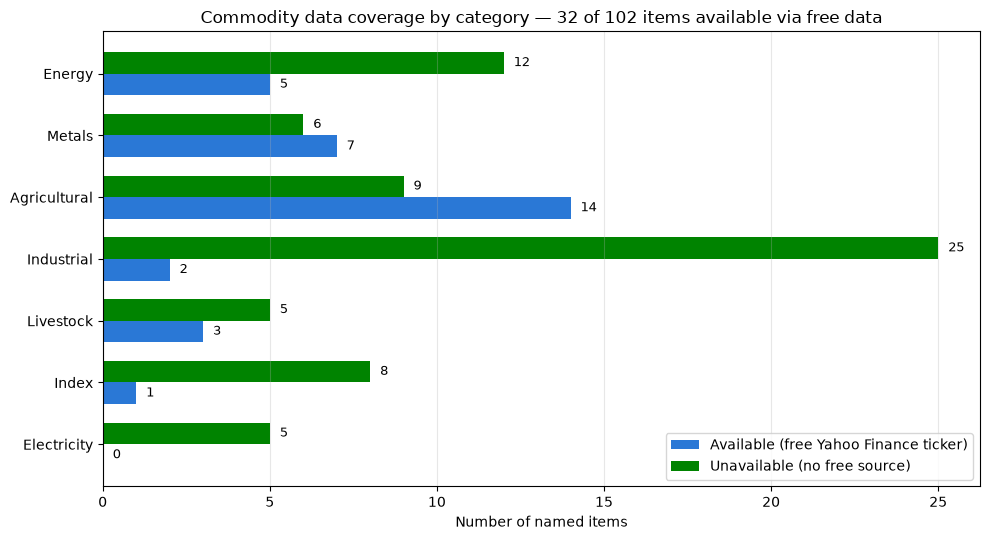

In [8]:
categories = ["Energy", "Metals", "Agricultural", "Industrial", "Livestock", "Index", "Electricity"]
available_counts = [5, 7, 14, 2, 3, 1, 0]
total_counts = [17, 13, 23, 27, 8, 9, 5]
unavailable_counts = [t - a for t, a in zip(total_counts, available_counts)]

y = np.arange(len(categories))
bar_h = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(y + bar_h / 2, available_counts, height=bar_h, color="#2a78d6", label="Available (free Yahoo Finance ticker)")
ax.barh(y - bar_h / 2, unavailable_counts, height=bar_h, color="#008300", label="Unavailable (no free source)")

for yi, (avail, unavail) in enumerate(zip(available_counts, unavailable_counts)):
    ax.text(avail + 0.3, yi + bar_h / 2, str(avail), va="center", fontsize=9)
    ax.text(unavail + 0.3, yi - bar_h / 2, str(unavail), va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(categories)
ax.set_xlabel("Number of named items")
total_available = sum(available_counts)
total_items = sum(total_counts)
ax.set_title(f"Commodity data coverage by category — {total_available} of {total_items} items available via free data")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()